# task 003 modeling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import precision_score
# from sklearn.metrics import recall_score
# from sklearn.metrics import f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import precision_score, recall_score, f1_score
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV









هدف این مرحله:
<br>
ساخت مدلی مناسب برای تشخیص ژن هایی که با فرایند پیری سلولی ارتباط دارند

    target=1 
<br>
ژن مرتبط با پیری
<br>

    target=0
<br>
ژن غیرمرتبط با پیری
<br>

# بخش اول: Modeling understanding

    سؤال 1: Modeling در فرآیند CRISP-DM چیست؟


مرحله Modeling چهارمین مرحله از فرآیند CRISP-DM است. در این مرحله، با استفاده از داده‌هایی که در مراحل قبلی آماده شده‌اند، یک یا چند مدل یادگیری ماشین ساخته می‌شود تا بتواند الگوهای موجود در داده را یاد بگیرد و متغیر هدف را پیش‌بینی کند

در پروژه حاضر، هدف مدل‌سازی این است که بر اساس الگوی بیان ژن‌ها، ژن‌های مرتبط با پیری سلولی شناسایی شوند

    سؤال 2: هدف اصلی مرحله Modeling چیست؟



هدف اصلی این مرحله ساخت مدلی است که بتواند با استفاده از ویژگی‌های ورودی، متغیر هدف را پیش‌بینی کند. علاوه بر پیش‌بینی، مدل باید بتواند اطلاعات مفیدی درباره اهمیت ویژگی‌ها و الگوهای موجود در داده ارائه دهد

    سؤال 3: ماشین لرنینگ (Machine Learning) چیست؟

یادگیری ماشین شاخه‌ای از هوش مصنوعی است که در آن الگوریتم‌ها از داده‌ها یاد می‌گیرند و بدون اینکه قوانین به صورت مستقیم برای آن‌ها تعریف شود، می‌توانند پیش‌بینی یا تصمیم‌گیری انجام دهند

    سؤال 4: داده‌کاوی (Data Mining) چیست؟

داده‌کاوی فرآیند استخراج الگوها، روابط و دانش مفید از داده‌های بزرگ است. هدف اصلی آن کشف اطلاعاتی است که به راحتی از طریق مشاهده مستقیم داده‌ها قابل تشخیص نیست

    سؤال 5: تفاوت Data Mining و Machine Learning چیست؟

Data Mining یک فرآیند کلی برای کشف دانش از داده‌ها است، در حالی که Machine Learning مجموعه‌ای از الگوریتم‌ها برای یادگیری الگوها از داده‌ها محسوب می‌شود

    سوال 6: Supervised Learning چیست؟

در Supervised Learning ، داده‌ها دارای برچسب هستند و مدل با استفاده از نمونه‌های دارای برچسب آموزش می‌بیند تا بتواند برچسب نمونه‌های جدید را پیش‌بینی کند.

    سوال 7: Unsupervised Learning چیست؟

در Unsupervised Learning ، داده‌ها برچسب ندارند و هدف مدل کشف ساختارها، خوشه‌ها یا روابط پنهان بین نمونه‌ها است

    سوال 8: Semi-Supervised Learning چیست؟

در Semi-Supervised Learning ، بخشی از داده‌ها دارای برچسب و بخش دیگری فاقد برچسب هستند و مدل از هر دو نوع داده برای یادگیری استفاده می‌کند.

    سوال 9: Reinforcement Learning چیست؟

در Reinforcement Learning ، یک عامل با تعامل با محیط و دریافت پاداش یا جریمه، به تدریج بهترین تصمیم یا استراتژی را یاد می‌گیرد

    سؤال 10: طبقه‌بندی (Classification) چیست؟

Classification به معنای پیش‌بینی یک برچسب مشخص برای هر نمونه است. در این پروژه، مدل باید تشخیص دهد که یک ژن مرتبط با پیری سلولی است یا غیرمرتبط با پیری سلولی

    سؤال 11: رگرسیون (Regression) چیست؟

Regression به معنای پیش‌بینی یک مقدار عددی پیوسته است. برای مثال، پیش‌بینی قیمت خانه یا میزان بیان یک ژن

    سؤال 12: خوشه‌بندی (Clustering) چیست؟

Clustering فرآیند گروه‌بندی نمونه‌های مشابه در خوشه‌های مختلف است، بدون اینکه از قبل برچسبی برای داده‌ها وجود داشته باشد

    سؤال 13: با توجه به هدف پروژه  این مسئله از چه نوعی است؟

در این پروژه، هدف پیش‌بینی مقدار Target برای هر ژن است. از آنجا که Target فقط دو مقدار 0 و 1 دارد، این مسئله در دسته طبقه‌بندی دودویی (Binary Classification) قرار می‌گیرد

    سؤال 14: آیا پروژه حاضر از نوع Supervised Learning است؟ دلیل خود را توضیح دهید

بله، این پروژه از نوع Supervised Learning است. دلیل آن این است که برای هر ژن یک برچسب مشخص به نام Target وجود دارد و مدل با استفاده از این برچسب‌ها آموزش می‌بیند تا بتواند کلاس ژن‌های جدید را پیش‌بینی کند

    سؤال 15: با توجه به هدف پروژه، چه نوع مدل‌سازی برای این مسئله مناسب‌تر است؟

با توجه به اینکه هدف پروژه پیش‌بینی یکی از دو کلاس مرتبط با پیری یا غیرمرتبط با پیری است، استفاده از مدل‌های طبقه‌بندی (Classification Models) برای این مسئله مناسب است اما اگر به دنبال بهترین نتیجه هستیم باید همه ی الگوریتم هارو تست کنیم و بعد ارزیابی کنیم

# بخش دوم: Problem definition

    سوال 16: مسئله پروژه حاضر از چه نوعی است؟

در این پروژه هدف پیش‌بینی مقدار Target برای هر ژن است. از آنجا که Target فقط دو مقدار 0 و 1 دارد، این مسئله از نوع طبقه‌بندی دودویی یا Binary Classification است

    سوال 17: چرا این پروژه یک مسئله Classification است؟

در این پروژه مدل باید برای هر ژن یکی از دو کلاس ممکن را پیش‌بینی کند. خروجی مدل یک برچسب است و نه یک مقدار عددی. به همین دلیل این پروژه در دسته مسائل Classification قرار می‌گیرد

    سوال 18: چرا این پروژه Regression نیست؟

در مسائل Regression هدف پیش‌بینی یک مقدار عددی پیوسته است. اما در این پروژه هدف پیش‌بینی یک کلاس مشخص است. بنابراین خروجی پروژه یک مقدار عددی پیوسته نیست و این مسئله Regression محسوب نمی‌شود

    سوال 19: چرا این پروژه Clustering نیست؟

در Clustering داده‌ها برچسب ندارند و هدف فقط گروه‌بندی نمونه‌های مشابه است. اما در این پروژه برای هر ژن یک برچسب Target وجود دارد و مدل باید این برچسب را پیش‌بینی کند. بنابراین این پروژه از نوع Clustering نیست

    سوال 20: چرا این پروژه Supervised Learning است؟

زیرا برای هر ژن مقدار Target مشخص شده است و مدل با استفاده از این برچسب‌ها آموزش می‌بیند. وجود متغیر هدف باعث می‌شود این پروژه در دسته یادگیری نظارت‌شده قرار بگیرد

    سوال 21: متغیر هدف در این پروژه چیست؟

متغیر هدف ستون Target است. این ستون مشخص می‌کند که هر ژن مرتبط با پیری سلولی است یا خیر

    سوال 22: چند کلاس در متغیر هدف وجود دارد؟

متغیر Target شامل دو کلاس است. کلاس 0 نشان‌دهنده ژن غیرمرتبط با پیری و کلاس 1 نشان‌دهنده ژن مرتبط با پیری است

    سوال 23: آیا این پروژه Binary Classification است یا Multi-Class Classification؟

از آنجا که فقط دو کلاس در متغیر هدف وجود دارد، این پروژه از نوع Binary Classification است

    سوال 24: اگر ستون Target حذف شود، مسئله به چه نوعی تبدیل می‌شود؟

اگر ستون Target حذف شود، داده‌ها دیگر برچسب نخواهند داشت. در این حالت مسئله از یک مسئله Supervised Learning به یک مسئله Unsupervised Learning تبدیل می‌شود و می‌توان از روش‌هایی مانند Clustering برای تحلیل داده‌ها استفاده کرد

    سوال 25: چه معیارهایی برای ارزیابی عملکرد مدل در این پروژه اهمیت دارند؟

در این پروژه مهم‌ترین معیارها Accuracy و Precision و Recall و F1-score هستند. همچنین استفاده از Confusion Matrix و ROC Curve و AUC می‌تواند تصویر دقیق‌تری از عملکرد مدل ارائه دهد. از آنجا که هدف شناسایی ژن‌های مرتبط با پیری است، معیار Recall اهمیت زیادی دارد، زیرا از دست دادن ژن‌های مرتبط با پیری می‌تواند نتایج پژوهش را تحت تأثیر قرار دهد

# بخش سوم: Select modeling technique

    سوال 26: چه الگوریتم‌هایی برای مسئله طبقه‌بندی دودویی مناسب هستند؟

برای مسائل Binary Classification الگوریتم‌های مختلفی وجود دارند. در این پروژه مناسب‌ترین گزینه‌ها Logistic Regression و Decision Tree و Random Forest هستند. این الگوریتم‌ها هم از نظر عملکرد و هم از نظر امکان تفسیر نتایج برای داده‌های بیان ژن مناسب هستند

    سوال 27: مزایا و معایب Logistic Regression را بررسی کنید

مهم‌ترین مزیت Logistic Regression سادگی و سرعت بالای آن است. این مدل به راحتی آموزش می‌بیند و نتایج آن قابل تفسیر هستند. همچنین به عنوان یک مدل پایه برای مقایسه سایر مدل‌ها بسیار مناسب است.

مهم‌ترین محدودیت آن این است که بیشتر روابط خطی را مدل می‌کند و ممکن است نتواند الگوهای پیچیده بین ژن‌ها را به خوبی یاد بگیرد

    سوال 28: مزایا و معایب Decision Tree را بررسی کنید

Decision Tree یکی از قابل تفسیرترین مدل‌های یادگیری ماشین است. قوانین تصمیم‌گیری آن به صورت درخت نمایش داده می‌شوند و می‌توان به راحتی فهمید که کدام ویژگی‌ها در تصمیم‌گیری نقش بیشتری دارند.

مهم‌ترین محدودیت این مدل احتمال بیش‌برازش است. اگر درخت بیش از حد رشد کند، ممکن است عملکرد آن روی داده‌های جدید کاهش پیدا کند

    سوال 29: مزایا و معایب Random Forest را بررسی کنید

Random Forest مجموعه‌ای از چندین Decision Tree است و معمولاً دقت بالاتری نسبت به یک درخت تصمیم دارد. این مدل در برابر نویز و داده‌های پرت مقاوم‌تر است و احتمال بیش‌برازش در آن کمتر است.

مهم‌ترین محدودیت آن این است که نسبت به Decision Tree تفسیرپذیری کمتری دارد و زمان آموزش آن نیز بیشتر است

    سوال 30: کدام یک از مدل‌های Logistic Regression و Decision Tree و Random Forest برای این پروژه مناسب‌تر به نظر می‌رسند؟

هر سه مدل برای این پروژه مناسب هستند، اما نقش آن‌ها متفاوت است. Logistic Regression به عنوان مدل پایه برای مقایسه استفاده می‌شود. Decision Tree به دلیل قابلیت تفسیر بالا و امکان شناسایی ژن‌های مهم ارزش زیادی دارد. Random Forest معمولاً بهترین عملکرد را در داده‌های پیچیده مانند داده‌های بیان ژن دارد و می‌تواند روابط غیرخطی بین ویژگی‌ها را بهتر یاد بگیرد. به همین دلیل انتظار می‌رود Random Forest از نظر دقت عملکرد بهتری داشته باشد، در حالی که Decision Tree از نظر تفسیر نتایج مناسب‌تر است

# بخش چهارم: Generate test design

    سوال 31: چرا داده را به مجموعه آموزش و آزمون تقسیم می‌کنیم؟

اگر مدل را روی تمام داده‌ها آموزش دهیم، نمی‌توانیم عملکرد واقعی آن را ارزیابی کنیم. به همین دلیل داده به دو بخش آموزش و آزمون تقسیم می‌شود. مدل روی داده‌های آموزش یاد می‌گیرد و سپس روی داده‌های آزمون ارزیابی می‌شود تا مشخص شود روی داده‌های جدید چقدر عملکرد مناسبی دارد

    سوال 32: اگر از تمام داده‌ها برای آموزش مدل استفاده کنیم چه مشکلی ایجاد می‌شود؟

اگر مدل روی تمام داده‌ها آموزش ببیند، ممکن است الگوهای خاص همان داده‌ها را حفظ کند و روی داده‌های جدید عملکرد ضعیفی داشته باشد. در این حالت ارزیابی مدل قابل اعتماد نخواهد بود و احتمال بیش‌برازش افزایش پیدا می‌کند

    سوال 33: مفهوم Generalization چیست؟

Generalization به این معنا است که مدل بتواند روی داده‌هایی که قبلاً ندیده است نیز عملکرد خوبی داشته باشد. هدف اصلی مدل‌سازی فقط یادگیری داده‌های آموزشی نیست، بلکه پیش‌بینی صحیح روی داده‌های جدید است

    سوال 34: مفهوم Overfitting چیست؟

Overfitting زمانی رخ می‌دهد که مدل علاوه بر الگوهای اصلی داده، نویز و جزئیات غیرضروری داده‌های آموزشی را نیز یاد می‌گیرد. در این حالت عملکرد مدل روی داده‌های آموزشی بسیار خوب است، اما روی داده‌های آزمون عملکرد ضعیفی دارد

    سوال 35: مفهوم Underfitting چیست؟

Underfitting زمانی رخ می‌دهد که مدل نتواند الگوهای اصلی داده را یاد بگیرد. در این حالت مدل هم روی داده‌های آموزشی و هم روی داده‌های آزمون عملکرد ضعیفی دارد و دقت آن پایین است

    سوال 36: داده را به مجموعه آموزش و آزمون تقسیم کنید

In [ ]:

df = pd.read_csv('gse63577_prepared.csv')
# df

# X = df.drop(columns=["Target"])
X = df.drop(columns=[
    "Target",
    "ensembl_gene_id",
    "external_gene_id",
    "gene_biotype",
    "Difference",
    "Abs_Difference",
    "Log2_Fold_Change"
])
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

در این مرحله 80 درصد داده‌ها برای آموزش مدل و 20 درصد برای آزمون در نظر گرفته شد

    سوال 37: تعداد نمونه‌های مجموعه آموزش و آزمون را گزارش کنید


In [10]:
print("Train :", X_train.shape[0])
print("Test :", X_test.shape[0])

Train : 45039
Test : 11260


# بخش پنجم: Logistic regression

    سوال 38: Logistic Regression چیست و چگونه کار می‌کند؟

Logistic Regression یکی از ساده‌ترین و پرکاربردترین الگوریتم‌های طبقه‌بندی است. این مدل احتمال تعلق هر نمونه به کلاس 1 را محاسبه می‌کند و بر اساس یک آستانه مشخص، نمونه را در یکی از دو کلاس قرار می‌دهد

    سوال 39: مدل Logistic Regression را ایجاد کنید

In [ ]:

log_model = LogisticRegression(max_iter=1000, random_state=42)

    سوال 40: مدل را با داده‌های آموزشی آموزش دهید

In [ ]:



log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

    سوال 41: ضرایب مدل را استخراج کنید

In [13]:
coef_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": log_model.coef_[0]
})

coef_df.head()

,Feature,Coefficient
0,BJ_Y1,0.772450
1,BJ_Y2,-0.401529
2,BJ_Y3,-0.420753
3,BJ_OLD_1,-0.618275
4,BJ_OLD_2,0.636179


    سوال 42: پیش‌بینی روی داده‌های آزمون انجام دهید

In [14]:
y_pred_log = log_model.predict(X_test)

y_pred_log[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

    سوال 43: Accuracy مدل را محاسبه کنید

In [ ]:

log_accuracy = accuracy_score(y_test, y_pred_log)

print(log_accuracy)

0.9461811722912966


    سوال 44: Precision مدل را محاسبه کنید

In [ ]:

log_precision = precision_score(y_test, y_pred_log)

print(log_precision)

0.8258145363408521


    سوال 45: Recall مدل را محاسبه کنید

In [ ]:

log_recall = recall_score(y_test, y_pred_log)

print(log_recall)

0.5852575488454707


    سوال 46: F1-score مدل را محاسبه کنید

In [ ]:

log_f1 = f1_score(y_test, y_pred_log)

print(log_f1)

0.685031185031185


    سوال 47: احتمال تعلق هر ژن به کلاس مرتبط با پیری را استخراج کنید

In [19]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]

y_prob_log[:10]

array([0.02086057, 0.14318402, 0.0210352 , 0.0210284 , 0.02743368,
       0.02122407, 0.02099528, 0.9704185 , 0.02239316, 0.02136014])

    سوال 48: مهم‌ترین ویژگی‌ها را بر اساس ضرایب مدل تحلیل کنید

In [20]:
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Abs_Coefficient", ascending=False).head(10)

,Feature,Coefficient,Abs_Coefficient
6,IMR90_Y1,4.152410,4.152410
28,MRC_5_PD72_2,2.483520,2.483520
9,IMR90_O1,-2.269213,2.269213
25,MRC_5_PD32_2,-2.147004,2.147004
14,WI_38_Y3,2.045700,2.045700
29,MRC_5_PD72_3,-1.825332,1.825332
26,MRC_5_PD32_3,1.711045,1.711045
20,HFF_PD16_3,-1.381105,1.381105
18,HFF_PD16_1,1.352294,1.352294
13,WI_38_Y2,-1.292183,1.292183


# بخش ششم: Decision tree

    سوال 49: Decision Tree چیست و چگونه کار می‌کند؟

Decision Tree یکی از الگوریتم‌های یادگیری نظارت‌شده است که با استفاده از مجموعه‌ای از قوانین تصمیم‌گیری، داده‌ها را به گروه‌های مختلف تقسیم می‌کند. این مدل در هر مرحله ویژگی‌ای را انتخاب می‌کند که بهترین جداسازی بین کلاس‌ها را ایجاد کند و در نهایت نمونه‌ها را به کلاس‌های مختلف اختصاص می‌دهد

    سوال 50: چرا Decision Tree برای این پروژه انتخاب شده است؟

Decision Tree به دلیل قابلیت تفسیر بالا انتخاب شده است. برخلاف بسیاری از مدل‌های پیچیده، می‌توان مسیر تصمیم‌گیری درخت را مشاهده کرد و فهمید که کدام ژن‌ها بیشترین تأثیر را در تشخیص پیری سلولی داشته‌اند. این موضوع برای پروژه‌های زیستی و ژنتیکی اهمیت زیادی دارد

    سوال 51: مدل Decision Tree را ایجاد کنید

In [ ]:

tree_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

    سوال 52: مدل را با داده‌های آموزشی آموزش دهید

In [22]:
tree_model.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

    سوال 53: پیش‌بینی روی داده‌های آزمون انجام دهید

In [23]:
y_pred_tree = tree_model.predict(X_test)

y_pred_tree[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

    سوال 54: Accuracy مدل را محاسبه کنید

In [ ]:

tree_accuracy = accuracy_score(y_test, y_pred_tree)

print(tree_accuracy)

0.9579040852575489


Accuracy نشان می‌دهد چه درصدی از ژن‌ها به درستی طبقه‌بندی شده‌اند

    سوال 55: Precision و Recall و F1-score مدل را محاسبه کنید

In [ ]:

tree_precision = precision_score(y_test, y_pred_tree)
tree_recall = recall_score(y_test, y_pred_tree)
tree_f1 = f1_score(y_test, y_pred_tree)

print("Precision:", tree_precision)
print("Recall:", tree_recall)
print("F1-score:", tree_f1)

Precision: 0.8638392857142857
Recall: 0.6873889875666075
F1-score: 0.7655786350148368


در این پروژه، Recall اهمیت زیادی دارد زیرا هدف شناسایی ژن‌های مرتبط با پیری است

    سوال 56: عمق درخت را گزارش کنید

In [26]:
print(tree_model.get_depth())

5


هرچه عمق درخت بیشتر باشد، احتمال بیش‌برازش نیز بیشتر می‌شود

    سوال 57: تعداد برگ‌های درخت را گزارش کنید

In [27]:
print(tree_model.get_n_leaves())

29


تعداد زیاد برگ‌ها معمولاً نشان‌دهنده پیچیدگی بیشتر مدل است

    سوال 58: اهمیت ویژگی‌ها را استخراج کنید

In [28]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tree_model.feature_importances_
})

importance_df.sort_values("Importance", ascending=False).head(10)

,Feature,Importance
30,Young_Mean,0.836941
31,Old_Mean,0.113243
0,BJ_Y1,0.015411
23,HFF_PD74_3,0.013230
21,HFF_PD74_1,0.008756
20,HFF_PD16_3,0.006703
12,WI_38_Y1,0.004450
16,WI_38_O2,0.000444
7,IMR90_Y2,0.000357
9,IMR90_O1,0.000310


    سوال 59: مهم‌ترین ژن‌های شناسایی‌شده توسط Decision Tree را تحلیل کنید

مدل Decision Tree توانست به Accuracy برابر با 95.8 درصد دست پیدا کند که نسبت به Logistic Regression عملکرد بهتری داشت. همچنین مقدار Precision برابر با 0.864 و Recall برابر با 0.687 نشان می‌دهد که مدل علاوه بر دقت بالا، توانایی بهتری در شناسایی ژن‌های مرتبط با پیری داشته است. مقدار F1-score برابر با 0.766 نیز نشان‌دهنده تعادل مناسب بین Precision و Recall است.

درخت تصمیم با عمق 5 و 29 برگ ساخته شده است. این موضوع نشان می‌دهد که مدل نسبتاً ساده باقی مانده و احتمال بیش‌برازش شدید در آن کمتر است.

بررسی اهمیت ویژگی‌ها نشان می‌دهد که مدل بیشترین وابستگی را به دو ویژگی Young_Mean و Old_Mean دارد. مقدار اهمیت Young_Mean برابر با 0.8369 و Old_Mean برابر با 0.1132 است. این دو ویژگی در مجموع تقریباً تمام تصمیم‌گیری مدل را تشکیل داده‌اند و سایر ویژگی‌ها سهم بسیار کمتری داشته‌اند.

پس از این دو ویژگی، ژن‌های BJ_Y1 و HFF_PD74_3 و HFF_PD74_1 بیشترین تأثیر را در تصمیم‌گیری مدل داشته‌اند. بنابراین این ژن‌ها می‌توانند به عنوان ژن‌های مهم و مؤثر در فرآیند پیری سلولی در مطالعات بعدی مورد توجه قرار گیرند.

نکته مهم این است که مدل عمدتا بر اساس تفاوت میانگین بیان ژن‌ها بین سلول‌های جوان و پیر تصمیم‌گیری کرده است. این نتیجه از نظر زیستی منطقی است، زیرا ژن‌هایی که تغییر بیان قابل توجهی بین دو گروه دارند، احتمال بیشتری دارد که با فرآیند پیری سلولی ارتباط داشته باشند.

در مجموع، نتایج نشان می‌دهد که Decision Tree توانسته الگوی مناسبی برای تشخیص ژن‌های مرتبط با پیری سلولی یاد بگیرد و در مقایسه با Logistic Regression عملکرد بهتری از نظر Accuracy و Recall و F1-score ارائه داده است. همچنین به دلیل ساختار قابل تفسیر درخت، این مدل امکان شناسایی ژن‌های مهم و تحلیل نقش آن‌ها در فرآیند پیری را فراهم می‌کند

# بخش هفتم: Random forest

    سوال 60: Random Forest چیست و چگونه کار می‌کند؟

Random Forest یک الگوریتم یادگیری نظارت‌شده است که از تعداد زیادی Decision Tree تشکیل شده است. هر درخت روی یک نمونه تصادفی از داده‌ها آموزش می‌بیند و در نهایت تصمیم نهایی بر اساس رأی اکثریت درخت‌ها گرفته می‌شود

    سوال 61: چرا Random Forest برای این پروژه انتخاب شده است؟

داده‌های بیان ژن معمولاً دارای روابط پیچیده و غیرخطی هستند. Random Forest می‌تواند این روابط را بهتر از مدل‌های خطی یاد بگیرد. همچنین این مدل قابلیت محاسبه Feature Importance را دارد و می‌تواند ژن‌های مهم را شناسایی کند

    سوال 62: مدل Random Forest را ایجاد کنید

In [ ]:

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

    سوال 63: مدل را با داده‌های آموزشی آموزش دهید

In [30]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

    سوال 64: پیش‌بینی روی داده‌های آزمون انجام دهید

In [31]:
y_pred_rf = rf_model.predict(X_test)

y_pred_rf[:10]

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0])

    سوال 65: Accuracy مدل را محاسبه کنید

In [ ]:

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print(rf_accuracy)

0.9846358792184725


    سوال 66: Precision و Recall و F1-score مدل را محاسبه کنید

In [ ]:

rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Precision:", rf_precision)
print("Recall:", rf_recall)
print("F1-score:", rf_f1)

Precision: 0.9288928892889289
Recall: 0.91651865008881
F1-score: 0.9226642825212338


YYeeeeeeeeeeeeeeeeeeesssssssssss

    سوال 67: اهمیت ویژگی‌ها را استخراج کنید

In [35]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance.sort_values("Importance", ascending=False).head(10)

,Feature,Importance
30,Young_Mean,0.110031
13,WI_38_Y2,0.083343
6,IMR90_Y1,0.081428
14,WI_38_Y3,0.068538
12,WI_38_Y1,0.060129
0,BJ_Y1,0.043653
9,IMR90_O1,0.043343
19,HFF_PD16_2,0.040738
31,Old_Mean,0.036997
2,BJ_Y3,0.034910


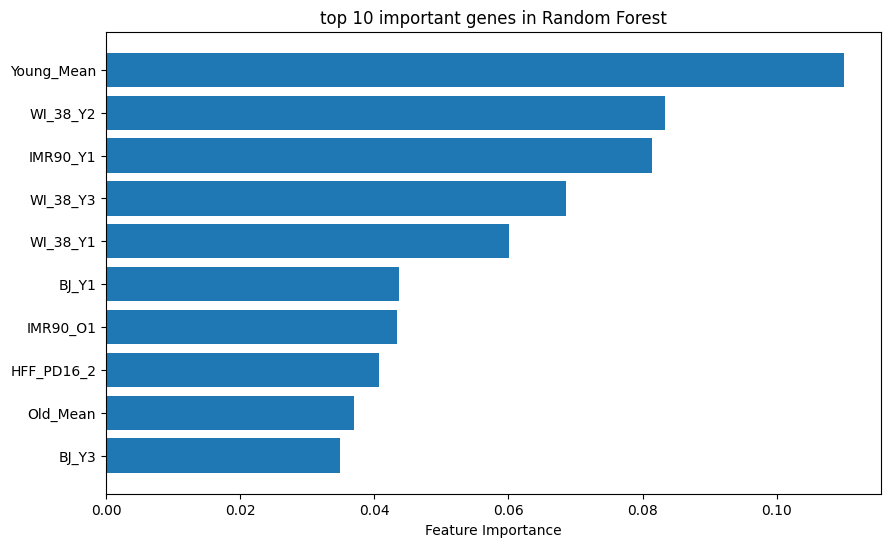

In [39]:

top10 = rf_importance.sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.xlabel("Feature Importance")
plt.title("top 10 important genes in Random Forest")
plt.gca().invert_yaxis()
plt.show()

    سوال 68: مهم‌ترین ژن‌های شناسایی‌شده توسط Random Forest را تحلیل کنید

بررسی اهمیت ویژگی‌ها نشان می‌دهد که مدل Random Forest تصمیم‌گیری خود را بر اساس مجموعه‌ای از ژن‌ها انجام داده است و برخلاف Decision Tree که بیشتر به دو ویژگی Young_Mean و Old_Mean وابسته بود، در این مدل چندین ژن به طور همزمان نقش مهمی داشته‌اند

مهم‌ترین ویژگی مدل Young_Mean با مقدار اهمیت 0.110 است. پس از آن ژن‌های WI_38_Y2 و IMR90_Y1 و WI_38_Y3 و WI_38_Y1 بیشترین اهمیت را داشته‌اند. همچنین ژن‌های BJ_Y1 و IMR90_O1 و HFF_PD16_2 و Old_Mean نیز در بین ویژگی‌های مهم قرار گرفته‌اند

این نتایج نشان می‌دهد که مدل Random Forest تنها به میانگین بیان ژن‌ها وابسته نیست و از اطلاعات مربوط به نمونه‌های مختلف سلول‌های جوان و پیر برای تشخیص ژن‌های مرتبط با پیری استفاده کرده است. به همین دلیل، ژن‌هایی مانند WI_38_Y2 و IMR90_Y1 و WI_38_Y3 می‌توانند به عنوان ژن‌های کلیدی در فرآیند پیری سلولی در مطالعات آینده مورد بررسی قرار گیرند

در مجموع، Random Forest توانسته است مجموعه متنوع‌تری از ژن‌های مهم را شناسایی کند و تصویر کامل‌تری از الگوهای بیان ژن مرتبط با پیری سلولی ارائه دهد

    سوال 69: عملکرد Random Forest را با Logistic Regression و Decision Tree مقایسه کنید

In [42]:
who_is_best__data = {
    'model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.9461811722912966, 0.9579040852575489, 0.9846358792184725],
    'Precision': [0.8258145363408521, 0.8638392857142857, 0.9288928892889289],
    'Recall': [0.5852575488454707, 0.6873889875666075, 0.91651865008881],
    'F1-score': [0.685031185031185, 0.7655786350148368, 0.9226642825212338]
}

who_is_best = pd.DataFrame(who_is_best__data)
who_is_best

,model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.946181,0.825815,0.585258,0.685031
1,Decision Tree,0.957904,0.863839,0.687389,0.765579
2,Random Forest,0.984636,0.928893,0.916519,0.922664


نتایج نشان می‌دهد که Random Forest در تمام معیارهای ارزیابی بهترین عملکرد را داشته است. این مدل با Accuracy برابر با 98.5 درصد توانسته است بیشترین دقت را در طبقه‌بندی ژن‌ها به دست آورد. همچنین مقدار Recall برابر با 0.917 نشان می‌دهد که مدل بخش عمده‌ای از ژن‌های مرتبط با پیری را به درستی شناسایی کرده است

در مقایسه با Logistic Regression، مدل Random Forest هم دقت بالاتری دارد و هم تعداد بسیار کمتری از ژن‌های مرتبط با پیری را از دست می‌دهد. همچنین نسبت به Decision Tree نیز عملکرد بهتری در هر چهار معیار ارزیابی داشته است

بنابراین، با توجه به نتایج به‌دست‌آمده، Random Forest مناسب‌ترین مدل برای این پروژه است. این مدل علاوه بر دقت بالا، توانسته است روابط پیچیده بین ژن‌ها را بهتر یاد بگیرد و مجموعه گسترده‌تری از ژن‌های مهم را در فرآیند پیری سلولی شناسایی کند

# بخش هشتم: Hyperparameter tuning

    سوال 70: Hyperparameter چیست؟

Hyperparameter به تنظیماتی گفته می‌شود که قبل از آموزش مدل توسط برنامه نویس تعیین می‌شوند و مدل آن‌ها را از داده یاد نمی‌گیرد. این پارامترها بر نحوه آموزش مدل و پیچیدگی آن تأثیر می‌گذارند.

برای مثال، در Decision Tree پارامتر max_depth و در Random Forest پارامتر n_estimators از نوع Hyperparameter هستند

    سوال 71: چرا Hyperparameter Tuning انجام می‌شود؟

تنظیم Hyperparameter باعث می‌شود مدل تعادل بهتری بین دقت و توانایی تعمیم برقرار کند. اگر پارامترها به درستی انتخاب نشوند، مدل ممکن است دچار بیش‌برازش یا کم‌برازش شود. هدف Hyperparameter Tuning پیدا کردن بهترین ترکیب پارامترها برای بهبود عملکرد مدل است

    سوال 72: Grid Search چیست؟

Grid Search روشی است که در آن مجموعه‌ای از مقادیر مختلف برای Hyperparameterها تعریف می‌شود و مدل برای تمام ترکیب‌های ممکن آموزش داده می‌شود. در نهایت ترکیبی که بهترین عملکرد را داشته باشد انتخاب می‌شود

    سوال 73: Random Search چیست؟

در Random Search به جای بررسی تمام ترکیب‌های ممکن، تعدادی ترکیب به صورت تصادفی انتخاب و ارزیابی می‌شوند. این روش معمولاً سریع‌تر از Grid Search است و در مسائل بزرگ می‌تواند نتایج مناسبی ارائه دهد

    سوال 74: چه پارامترهایی برای Random Forest در این پروژه اهمیت دارند؟

n_estimators

max_depth

min_samples_split

min_samples_leaf

max_features

    سوال 75: GridSearchCV را برای Random Forest پیاده‌سازی کنید

In [ ]:

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, None], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the ver

    سوال 76: بهترین پارامترهای به دست آمده را گزارش کنید

In [53]:
print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


    سوال 77: بهترین مقدار F1-score را گزارش کنید

In [54]:
print(grid.best_score_)

0.9060212713837247


    سوال 78: مدل بهینه را استخراج کنید

In [56]:
best_rf = grid.best_estimator_

    سوال 79: عملکرد مدل بهینه را روی داده‌های آزمون محاسبه کنید

In [ ]:

y_pred_best = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))

Accuracy: 0.9847246891651865
Precision: 0.9228723404255319
Recall: 0.9245115452930728
F1-score: 0.9236912156166814


# بخش نهم: Model evaluation

    سوال 80: Confusion Matrix چیست؟

Confusion Matrix جدولی است که تعداد پیش‌بینی‌های صحیح و نادرست مدل را نشان می‌دهد. این جدول مشخص می‌کند که مدل چه تعداد نمونه را درست یا غلط در هر کلاس قرار داده است

    سوال 81: اجزای Confusion Matrix را توضیح دهید

True Positive (TP) ژن‌های مرتبط با پیری که مدل آن‌ها را درست تشخیص داده است

True Negative (TN) ژن‌های غیرمرتبط با پیری که مدل آن‌ها را درست تشخیص داده است

False Positive (FP) ژن‌های غیرمرتبط با پیری که مدل به اشتباه مرتبط با پیری تشخیص داده است

False Negative (FN) ژن‌های مرتبط با پیری که مدل آن‌ها را از دست داده است

    سوال 82: Confusion Matrix مدل Logistic Regression را رسم کنید

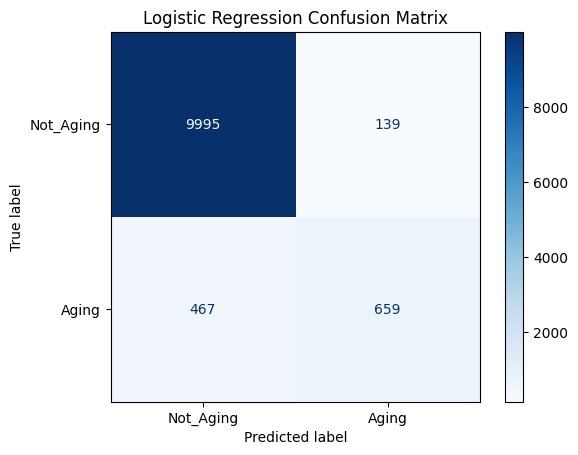

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_log = confusion_matrix(y_test, y_pred_log)

ConfusionMatrixDisplay(
    confusion_matrix=cm_log,
    display_labels=["Not_Aging", "Aging"]
).plot(cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

    سوال 83: Confusion Matrix مدل Decision Tree را رسم کنید

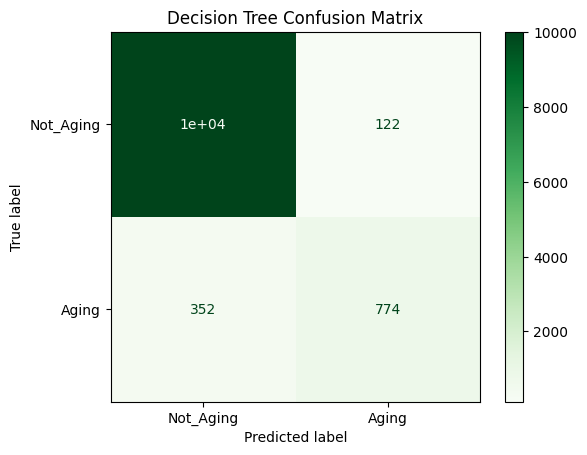

In [59]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=["Not_Aging", "Aging"]
).plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")
plt.show()

    سوال 84: Confusion Matrix مدل Random Forest را رسم کنید

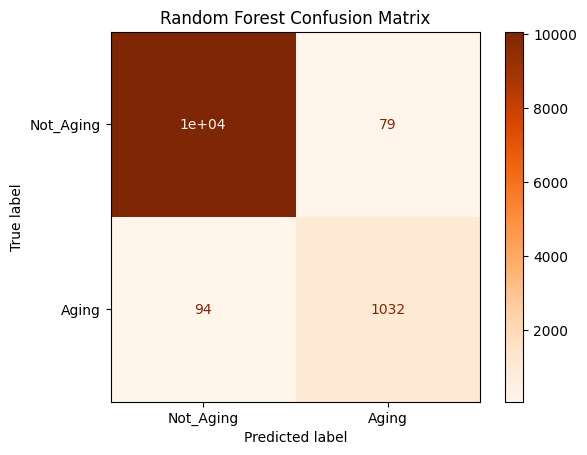

In [60]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Not_Aging", "Aging"]
).plot(cmap="Oranges")

plt.title("Random Forest Confusion Matrix")
plt.show()

    سوال 85: ROC Curve چیست؟

ROC Curve رابطه بین نرخ تشخیص درست و نرخ تشخیص غلط را در آستانه‌های مختلف نشان می‌دهد. هرچه منحنی به گوشه بالا سمت چپ نزدیک‌تر باشد، عملکرد مدل بهتر است

    سوال 86: AUC چیست؟

AUC یا Area Under Curve مساحت زیر منحنی ROC است. مقدار AUC بین 0.5 تا 1 قرار دارد. هرچه این مقدار به 1 نزدیک‌تر باشد، مدل توانایی بیشتری در جداسازی دو کلاس دارد

    سوال 87: مقدار AUC هر سه مدل را محاسبه کنید

In [ ]:
from sklearn.metrics import roc_auc_score


y_prob_rf = rf_model.predict_proba(X_test)[:, 1]


auc_log = roc_auc_score(y_test, y_prob_log)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression AUC:", auc_log)
print("Random Forest AUC:", auc_rf)

Logistic Regression AUC: 0.9770365731524394
Random Forest AUC: 0.9975469034651478


    سوال 88: اگر هدف اصلی پروژه شناسایی ژن‌های مرتبط با پیری باشد، کدام معیار اهمیت بیشتری دارد؟

در این پروژه Recall مهم‌ترین معیار ارزیابی است. دلیل آن این است که از دست دادن ژن‌های مرتبط با پیری اهمیت زیادی دارد. اگر مدل ژن‌های مرتبط با پیری را به اشتباه غیرمرتبط تشخیص دهد، ممکن است ژن‌های مهم از تحلیل‌های زیستی حذف شوند

با توجه به نتایج به دست آمده، مدل Random Forest با Recall برابر با 0.917 بهترین عملکرد را در شناسایی ژن‌های مرتبط با پیری داشته است و از این نظر مناسب‌ترین مدل برای پروژه محسوب می‌شود

# بخش دهم: Model comparison and final selection

    سوال 89: نتایج هر سه مدل را در یک جدول مقایسه‌ای قرار دهید

In [70]:
who_is_best

,model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.946181,0.825815,0.585258,0.685031
1,Decision Tree,0.957904,0.863839,0.687389,0.765579
2,Random Forest,0.984636,0.928893,0.916519,0.922664


    سوال 90: کدام مدل بیشترین Accuracy را دارد؟

بر اساس نتایج به دست آمده، Random Forest با Accuracy برابر با 0.984 بیشترین دقت را در طبقه‌بندی ژن‌ها داشته است

    سوال 91: کدام مدل بیشترین Recall را دارد؟

مدل Random Forest با Recall برابر با 0.916 بیشترین توانایی را در شناسایی ژن‌های مرتبط با پیری سلولی داشته است

    سوال 92: کدام مدل بیشترین F1-score را دارد؟

مدل Random Forest با F1-score برابر با 0.922 بهترین تعادل را بین Precision و Recall ایجاد کرده است.

    سوال 93: کدام مدل از نظر قابلیت تفسیر بهتر است؟

مدل Decision Tree از نظر قابلیت تفسیر بهترین مدل است، زیرا ساختار درخت به صورت مستقیم قابل مشاهده است و می‌توان مسیر تصمیم‌گیری مدل را بررسی کرد

    سوال 94: کدام مدل از نظر عملکرد کلی مناسب‌تر است؟

با در نظر گرفتن Accuracy و Precision و Recall و F1-score، مدل Random Forest بهترین عملکرد کلی را داشته است

    سوال 95: چرا Random Forest به عنوان مدل نهایی انتخاب می‌شود؟

Random Forest بالاترین Accuracy و بالاترین Recall و بالاترین F1-score را به دست آورده است. همچنین این مدل توانسته روابط پیچیده بین ژن‌ها را بهتر یاد بگیرد و مجموعه متنوع‌تری از ژن‌های مهم را شناسایی کند

    سوال 96: اگر هدف پروژه فقط شناسایی ژن‌های مرتبط با پیری باشد، کدام مدل مناسب‌تر است؟

در این پروژه هدف اصلی شناسایی ژن‌های مرتبط با پیری سلولی است. بنابراین Recall اهمیت بیشتری دارد و از این نظر Random Forest بهترین گزینه است

    سوال 97: مهم‌ترین ژن‌های شناسایی‌شده توسط Random Forest کدام هستند؟

بر اساس Feature Importance، ژن‌ها و ویژگی‌های مهم شامل Young_Mean و WI_38_Y2 و IMR90_Y1 و WI_38_Y3 و WI_38_Y1 هستند. این ژن‌ها بیشترین نقش را در تصمیم‌گیری مدل داشته‌اند

    سوال 98: محدودیت‌های مدل منتخب چیست؟

مهم‌ترین محدودیت Random Forest کاهش قابلیت تفسیر نسبت به Decision Tree است

    سوال 99: چه اقداماتی می‌تواند عملکرد مدل را در آینده بهبود دهد؟

برای بهبود عملکرد مدل می‌توان تعداد نمونه‌های آموزشی را افزایش داد، ژن‌های بیشتری را وارد تحلیل کرد، ویژگی‌های زیستی جدید استخراج کرد و روش‌های پیشرفته‌تر مانند XGBoost یا LightGBM را بررسی کرد

    سوال 100: جمع‌بندی نهایی مرحله Modeling را ارائه دهید

در این مرحله سه مدل Logistic Regression و Decision Tree و Random Forest ساخته و ارزیابی شدند. نتایج نشان داد که Random Forest بهترین عملکرد را در تشخیص ژن‌های مرتبط با پیری سلولی دارد و از نظر Accuracy و Recall و F1-score از دو مدل دیگر بهتر عمل کرده است. بنابراین این مدل به عنوان مدل نهایی پروژه انتخاب می‌شود و می‌تواند برای شناسایی ژن‌های کلیدی مرتبط با پیری سلولی و مطالعات زیستی آینده مورد استفاده قرار گیرد